In [1]:
import seaborn as sns

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np 

import h5py
from scipy.integrate import simpson
from scipy.optimize import curve_fit
from matplotlib.ticker import AutoMinorLocator

plt.rc('axes', linewidth=3, labelsize=22)
plt.rc('xtick', labelsize=22)  # fontsize of the x tick labels
plt.rc('ytick', labelsize=22)  # fontsize of the y tick labels
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'  # Axis labels
plt.rcParams['axes.titleweight'] = 'bold' 

sns.set_theme(font_scale=2.25)
sns.set_style("white")


In [2]:


def apply_ax_format(ax,xlabel="",ylabel="",title="",legend=False,inset=False):
    if not inset:
        ax.spines['bottom'].set_color('0')
        ax.spines['top'].set_color('1')
        ax.spines['right'].set_color('1')
        ax.spines['left'].set_color('0')
    ax.tick_params(which="both",direction='out', width=3, bottom=True, left=True)
    ax.grid(False)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    ax.xaxis.set_minor_locator(AutoMinorLocator(4))
    ax.yaxis.set_minor_locator(AutoMinorLocator(4))
    if legend:
        plt.setp(ax.get_legend().get_texts(), fontsize='22') # for legend text
        plt.setp(ax.get_legend().get_title(), fontsize='22') # for legend title



In [3]:


# Fit the resolution data to a polynomial for extrapolation
def poly_func(x, a, b, c):
    return a * x**2 + b * x + c

# Create a function to get resolution for any energy
def get_resolution(e,popt):
    return np.maximum(poly_func(e, *popt), 1e-10)  # Ensure non-zero resolution


# Perform Gaussian broadening using convolution with energy-dependent widths
def gaussian_broadening(dos, energy, sigmas):
    broadened_dos = np.zeros_like(dos)
    for i in range(len(energy)):
        # Create a Gaussian kernel centered at each energy point with width sigmas[i]
        kernel = np.exp(-0.5 * ((energy - energy[i]) / sigmas[i])**2)
        kernel /= simpson(kernel, energy)  # Normalize the kernel to preserve area
        broadened_dos += dos[i] * kernel  # Convolve DOS with Gaussian kernel
    return broadened_dos

def apply_gaussian_broadening(dos_data,metric='dos total (nm2/ps)',unit_cell_atoms=1):
    energy = dos_data['Energy Transfer (meV)'].values
    dos = dos_data[metric].values

    resolution_data = pd.read_csv('../data/hresolution.csv')
    res_energy = resolution_data['Energy (meV)'].values
    resolution = resolution_data['Resolution'].values
    popt, _ = curve_fit(poly_func, res_energy, resolution)
    
    # Create an array of sigmas for Gaussian broadening based on the resolution function
    sigmas = get_resolution(energy,popt) / np.sqrt(8 * np.log(2))  # Convert FWHM to sigma


    broadened_dos = gaussian_broadening(dos, energy, sigmas)

    # Area normalize both original and broadened DOS
    original_area = simpson(dos, energy)
    broadened_area = simpson(broadened_dos, energy)

    dos_normalized = dos / original_area
    #dos_normalized-=dos_normalized[0]
    broadened_dos_normalized = broadened_dos / broadened_area
    return dos_normalized #3*unit_cell_atoms*broadened_dos_normalized

In [4]:
results_directory=dict()
for temperature in np.arange(100,450,50):
    for subset in ["H2O","SiO2","Total"]:
        results_directory["../results/gromacs/pore/4nm/H2O/results_720_le/%d/%s/out_dos.h5" % (temperature,subset)]=(temperature,subset)

df_list=list()

min_energy=0
max_energy=1500
subset_map={"H2O":"$H_2O$","SiO2":"$SiO_2$","Total":"Total"}
for pdos_file,(temperature,subset) in results_directory.items():
    print(pdos_file)
    h5file=h5py.File(pdos_file)
    data_dict=dict()
    omega_shape=h5file["omega"][:].shape
    for k in h5file.keys():
        data_array=h5file[k][:]
        if data_array.shape != omega_shape or "_0" in k:
            continue
        units=h5file[k].attrs['units']
        data_dict["%s (%s)"%(k.replace("_"," "),units)]=data_array
    h5file.close()
    df_tmp=pd.DataFrame(data_dict).query("%f < `omega (rad/ps)` and `omega (rad/ps)` < %f"%(min_energy/0.6582,max_energy/0.6582))
    df_tmp["Energy Transfer (meV)"]=df_tmp["omega (rad/ps)"]*0.6582
    df_tmp["Normalized Count"]=apply_gaussian_broadening(df_tmp)
    df_tmp["Max Normalized Count"]=df_tmp["Normalized Count"]/df_tmp["Normalized Count"].max()
    df_tmp["Temperature (K)"]=temperature
    df_tmp["Subset"]=subset_map[subset]
    df_list.append(df_tmp)
        
df_dos_mdanse=pd.concat(df_list,ignore_index=True)
df_dos_mdanse

../results/gromacs/pore/4nm/H2O/results_720_le/100/H2O/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720_le/100/SiO2/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720_le/100/Total/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720_le/150/H2O/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720_le/150/SiO2/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720_le/150/Total/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720_le/200/H2O/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720_le/200/SiO2/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720_le/200/Total/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720_le/250/H2O/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720_le/250/SiO2/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720_le/250/Total/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720_le/300/H2O/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720_le/300/SiO2/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720_le/300/Total/out_do

,dos H (nm2/ps),dos M (nm2/ps),dos O (nm2/ps),dos total (nm2/ps),omega (rad/ps),omega window (au),time window (au),Energy Transfer (meV),Normalized Count,Max Normalized Count,Temperature (K),Subset,dos Si (nm2/ps)
0,0.006096,0.00015,0.000071,0.006086,0.007663,24.992791,9.999664e-01,0.005044,0.032728,0.611602,100,$H_2O$,NaN
1,0.006096,0.00015,0.000071,0.006086,0.015326,24.773604,9.998655e-01,0.010088,0.032728,0.611599,100,$H_2O$,NaN
2,0.006096,0.00015,0.000071,0.006086,0.022990,24.412557,9.996975e-01,0.015132,0.032728,0.611595,100,$H_2O$,NaN
3,0.006095,0.00015,0.000071,0.006086,0.030653,23.915914,9.994622e-01,0.020176,0.032728,0.611590,100,$H_2O$,NaN
4,0.006095,0.00015,0.000071,0.006086,0.038316,23.292189,9.991599e-01,0.025220,0.032727,0.611583,100,$H_2O$,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
104974,0.022303,NaN,0.002663,0.021722,38.277620,0.000000,6.339580e-18,25.194330,0.033545,0.493918,400,Total,0.001
104975,0.022303,NaN,0.002663,0.021723,38.285283,0.000000,1.002906e-17,25.199373,0.033546,0.493929,400,Total,0.001
104976,0.022303,NaN,0.002662,0.021723,38.292947,0.000000,1.484367e-17,25.204417,0.033546,0.493937,400,Total,0.001
104977,0.022304,NaN,0.002662,0.021723,38.300610,0.000000,2.781307e-17,25.209461,0.033547,0.493942,400,Total,0.001


In [5]:
results_directory=dict()
for temperature in np.arange(100,450,50):
    for subset in ["H2O","SiO2","Total"]:
        results_directory["../results/gromacs/pore/4nm/H2O/results_720_le/%d/%s/dos.csv" % (temperature,subset)]=(temperature,subset)

df_list=list()
for pdos_file,(temperature,subset) in results_directory.items():
    df_tmp=pd.read_csv(pdos_file,names=['Wave number $(cm^{-1})',"dos","dos(solid)","dos(diff)"],skiprows=1)
    df_tmp["Temperature (K)"]=temperature
    df_tmp["Subset"]=subset_map[subset]
    df_tmp['Energy Transfer (meV)']=df_tmp['Wave number $(cm^{-1})']*0.124
    dos=df_tmp["dos(solid)"].values
    energy=df_tmp["Energy Transfer (meV)"].values
    original_area = simpson(dos, energy)
    df_tmp["Normalized Count"] = apply_gaussian_broadening(df_tmp,metric="dos(solid)")
    df_tmp["Max Normalized Count"] = df_tmp["Normalized Count"]/df_tmp["Normalized Count"].max()
    df_list.append(df_tmp)

df_dos_gmx=pd.concat(df_list,ignore_index=True)
df_dos_gmx

,Wave number $(cm^{-1}),dos,dos(solid),dos(diff),Temperature (K),Subset,Energy Transfer (meV),Normalized Count,Max Normalized Count
0,0.000000,37.2917,0.000000,37.2917,100,$H_2O$,0.000000,0.000000,0.000000
1,0.162714,36.6465,-0.644711,37.2912,100,$H_2O$,0.020177,-0.000663,-0.012408
2,0.325428,37.9832,0.693614,37.2896,100,$H_2O$,0.040353,0.000713,0.013349
3,0.488143,36.4880,-0.798955,37.2870,100,$H_2O$,0.060530,-0.000822,-0.015376
4,0.650857,37.0367,-0.246547,37.2833,100,$H_2O$,0.080706,-0.000254,-0.004745
...,...,...,...,...,...,...,...,...,...
26245,202.579000,347.1860,334.563000,12.6234,400,Total,25.119796,0.046619,0.877805
26246,202.742000,346.5560,333.952000,12.6039,400,Total,25.140008,0.046533,0.876202
26247,202.905000,350.1740,337.590000,12.5845,400,Total,25.160220,0.047040,0.885747
26248,203.067000,345.9590,333.394000,12.5651,400,Total,25.180308,0.046456,0.874738


C:\Users\galavizp\AppData\Local\Temp\ipykernel_23236\1286391289.py:2: RuntimeWarning: divide by zero encountered in power
  return a*x**b+c


,Temperature (K),a(T),b(T),c(T),emax,$a_0$,$a_1$,$a_2$,$a_4$,$n_1$,$n_2$,$n_4$,$\Delta a_0$,$\Delta a_1$,$\Delta a_2$,$\Delta a_4$,Subset
0,100,0.002075,1.380018,0.000253,1.50,0.000190,0.001740,1.911572e-13,2.788069e-04,0.861906,9.468067e-11,0.138094,8.840091e-08,2.188169e-06,2.832717e-06,1.766823e-07,$H_2O$
1,100,0.002090,1.352007,0.000238,1.55,0.000164,0.001824,4.659849e-11,2.327142e-04,0.886871,2.265279e-08,0.113129,8.534894e-08,2.002343e-06,2.457172e-06,1.377801e-07,$H_2O$
2,100,0.001977,1.533847,0.000332,1.60,0.000179,0.001777,2.457302e-07,2.558331e-04,0.874066,1.208451e-04,0.125814,8.429932e-08,1.829666e-06,2.077581e-06,9.981223e-08,$H_2O$
3,100,0.002041,1.435206,0.000282,1.65,0.000137,0.001904,3.540266e-09,1.989515e-04,0.905414,1.683097e-06,0.094585,8.317646e-08,1.716839e-06,1.854165e-06,8.061661e-08,$H_2O$
4,100,0.002053,1.419457,0.000273,1.70,0.000109,0.001986,2.113281e-07,1.662449e-04,0.922662,9.818618e-05,0.077240,7.817353e-08,1.499861e-06,1.505929e-06,5.662571e-08,$H_2O$
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
646,400,0.002256,1.910966,0.001192,2.80,0.001080,0.000550,1.847577e-03,4.799061e-06,0.228948,7.690549e-01,0.001998,9.103523e-09,6.448382e-08,2.394549e-08,1.239476e-10,Total
647,400,0.002266,1.905714,0.001186,2.85,0.001081,0.000533,1.865789e-03,2.418137e-06,0.222004,7.769887e-01,0.001007,9.107863e-09,6.179114e-08,2.197827e-08,1.043969e-10,Total
648,400,0.002284,1.895688,0.001175,2.90,0.001075,0.000541,1.870650e-03,6.440968e-07,0.224289,7.754438e-01,0.000267,9.066943e-09,5.980042e-08,2.067862e-08,9.284837e-11,Total
649,400,0.002298,1.888615,0.001167,2.95,0.001064,0.000571,1.859277e-03,2.961972e-07,0.235022,7.648564e-01,0.000122,8.896884e-09,5.628590e-08,1.867064e-08,7.715819e-11,Total


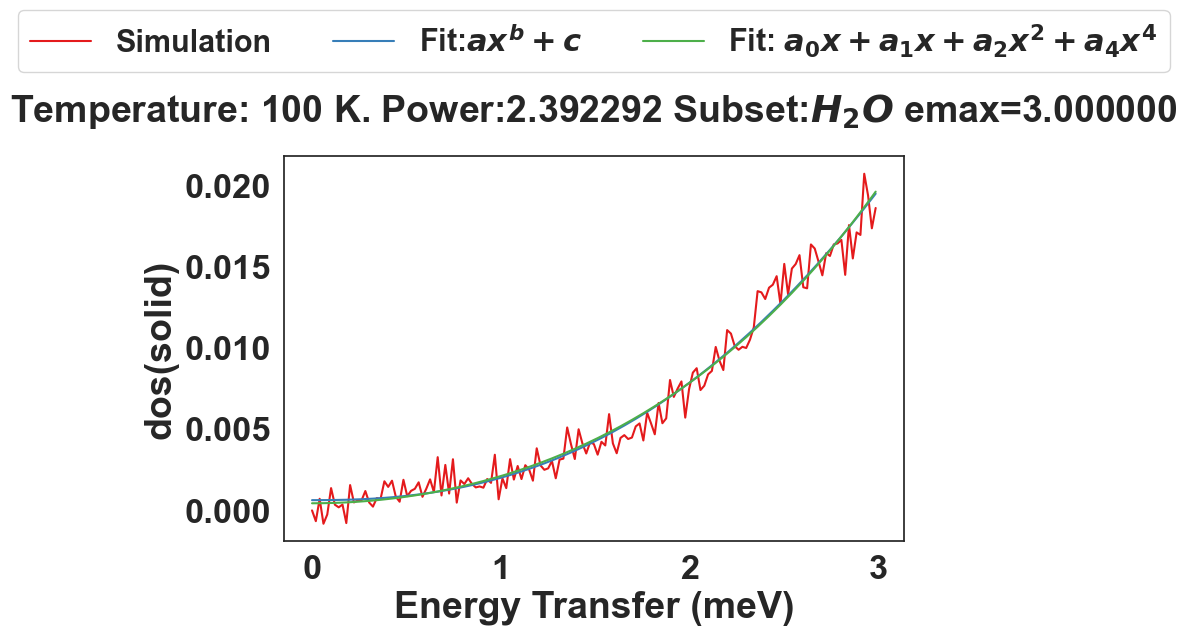

In [6]:
def power(x,a,b,c):
    return a*x**b+c

def taylor_series(x,a0,a1,a2,a4):
    return a0+a1*x+a2*x**2+a4*x**4

emax_l=1.5
emax_r=3
d_emax=0.05
df_data=df_dos_gmx.copy()
df_list=list()
for i,subset in enumerate(df_data["Subset"].unique()):
    data_list=list()
    for j,temperature in enumerate(df_data["Temperature (K)"].unique()):
        for emax in np.arange(emax_l,emax_r+d_emax,d_emax):  
            df_tmp=df_data.query("0 <= `Energy Transfer (meV)` <= %f and `Temperature (K)` == %d and Subset == '%s'"%(emax,temperature,subset))
            xdata=df_tmp["Energy Transfer (meV)"].values
            ydata=df_tmp["Normalized Count"].values
            popt, pcov = curve_fit(power, xdata, ydata,p0=[1,3,0],method='lm')
            popt_14, pcov_14 = curve_fit(taylor_series, xdata, ydata,p0=[1,1,1,1],bounds=([-np.inf,0,0,0],[np.inf,np.inf,np.inf,np.inf]),method='trf')
            
            norm=np.sum(np.abs(popt_14[1:]))
            cv_14=np.diag(pcov_14)
            data_list.append({
                "Temperature (K)":temperature
                , "a(T)":popt[0]
                , "b(T)":popt[1]
                , "c(T)":popt[2] 
                ,"emax":emax
                ,"$a_0$":popt_14[0]
                ,"$a_1$":popt_14[1]
                ,"$a_2$":popt_14[2]
                #,"$a_3$":popt_14[3]
                ,"$a_4$":popt_14[3]
                ,"$n_1$":popt_14[1]/norm
                ,"$n_2$":popt_14[2]/norm
                #,"$n_3$":popt_14[3]/norm
                ,"$n_4$":popt_14[3]/norm
                ,"$\\Delta a_0$":cv_14[0]
                ,"$\\Delta a_1$":cv_14[1]
                ,"$\\Delta a_2$":cv_14[2]
                #,"$\\Delta a_3$":cv_14[3]
                ,"$\\Delta a_4$":cv_14[3]
                             })
        if i>0 or j>0:
            continue

        fig, ax = plt.subplots(figsize=(8,5))
        df_fit=pd.concat([
            pd.DataFrame({"Energy Transfer (meV)":xdata,"dos(solid)":ydata,"data":"Simulation"})
            ,pd.DataFrame({"Energy Transfer (meV)":xdata,"dos(solid)": power(xdata, *popt),"data":"Fit:$ax^b+c$"})
            ,pd.DataFrame({"Energy Transfer (meV)":xdata,"dos(solid)": taylor_series(xdata, *popt_14),"data":"Fit: $a_0x+a_1x+a_2x^2+a_4x^4$"})
        ],ignore_index=True)
        sns.lineplot(data=df_fit
            , y='dos(solid)'
                 , x='Energy Transfer (meV)'
                 ,ax=ax
                ,hue='data'
                 ,palette='Set1'
                )
        ax.set_title("Temperature: %d K. Power:%f Subset:%s emax=%f"%(temperature,popt[1],subset,emax),pad=25)
        sns.move_legend(ax,'center',bbox_to_anchor=(0.5,1.3),ncol=4,fontsize=22,title_fontsize=22,title="")


    df_tmp=pd.DataFrame(data_list)
    df_tmp["Subset"]=subset
    df_list.append(df_tmp)
    
df_power=pd.concat(df_list,ignore_index=True)
    
df_power

In [7]:
df_power["Subset"].unique() 

array(['$H_2O$', '$SiO_2$', 'Total'], dtype=object)

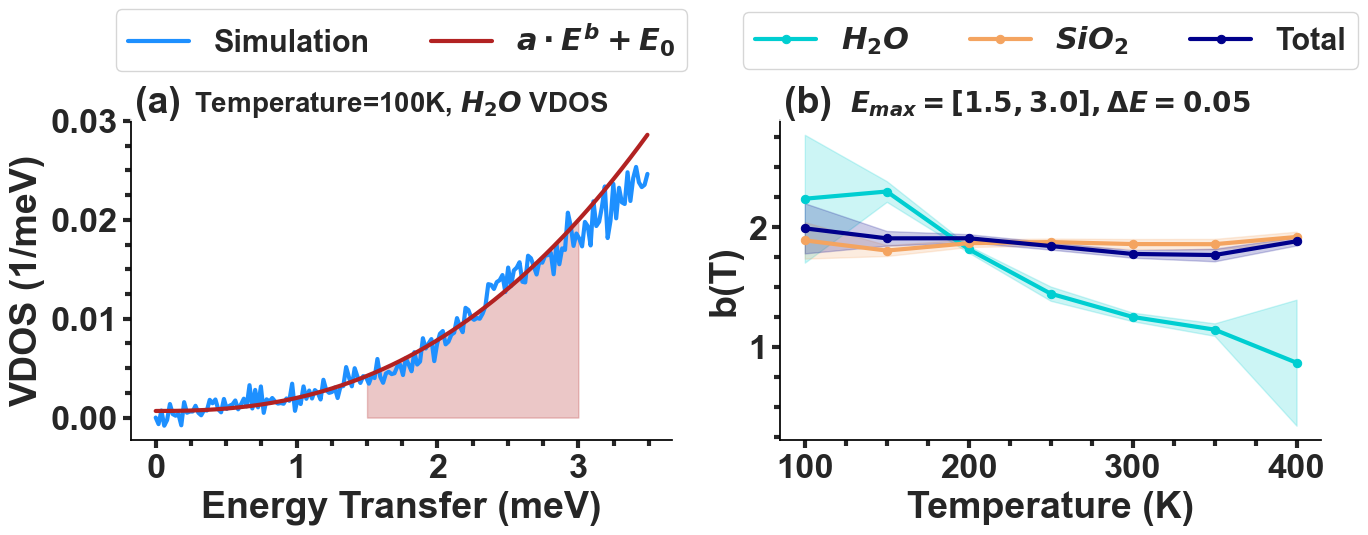

In [8]:
fig, axs = plt.subplots(ncols=2,figsize=(7*2,4))
labx=0.00625
laby=1.025
index=["(%s)"%x for x in list("abcdefghijkl")]

temperature=100
ax=axs[0]
subset="$H_2O$"
ax.text(labx, laby, index[0],weight='bold' ,transform=ax.transAxes)
df_tmp=df_data.query("`Temperature (K)`==%d and Subset == '%s' and `Energy Transfer (meV)` < %f"%(temperature,subset,emax_r+10*d_emax))
sns.lineplot(data=df_tmp
            ,y="Normalized Count"
            ,x="Energy Transfer (meV)"
            ,ax=ax
            ,lw=3
            ,label="Simulation" 
             ,color='dodgerblue'
       )
xdata=df_tmp["Energy Transfer (meV)"].values
ds=df_power.query("`Temperature (K)`==%d and Subset == '%s' and emax >= %f"%(temperature,subset,emax-d_emax))
a,b,c=ds[["a(T)","b(T)","c(T)"]].values[0]
df_fit=pd.DataFrame({"Energy Transfer (meV)":xdata,"Fitted VDOS (1/meV)": power(xdata,a,b,c),"data":"Fit:$ax^b+c$"})
sns.lineplot(data=df_fit
            ,y="Fitted VDOS (1/meV)"
            ,x="Energy Transfer (meV)"
            ,ax=ax
             ,lw=3
            ,label="$a\cdot E^b+E_0$" 
             ,color='firebrick'
       )


apply_ax_format(ax,xlabel="Energy Transfer (meV)",ylabel="VDOS (1/meV)")

legend_y=1.25
sns.move_legend(ax,'center',bbox_to_anchor=(0.5,legend_y),ncol=3,fontsize=22,title_fontsize=22,title="")
ax.set_title("Temperature=%dK, %s VDOS"%(temperature,subset),fontsize=20)
ymax=df_fit["Fitted VDOS (1/meV)"].max()
#ax.vlines(x=emax_l,ymin=0,ymax=ymax,colors='firebrick',linestyles='--')
#ax.vlines(x=3.5,ymin=0,ymax=ymax,colors='firebrick',linestyles='--')

xdata=np.linspace(emax_l,emax_r)
ax.fill_between(xdata, 0, power(xdata,a,b,c),color='firebrick', alpha=0.25)

ax=axs[1]
ax.text(labx, laby, index[1],weight='bold' ,transform=ax.transAxes)

sns.lineplot(data=df_power
            , y='b(T)'
                 , x='Temperature (K)'
                 ,ax=ax
                 ,marker='o'
#                 ,markerfacecolor="grey"
                 ,markeredgecolor=None
                ,hue='Subset'
             ,lw=3
             ,errorbar="sd"
                 ,palette=["darkturquoise","sandybrown","darkblue"]
                )


apply_ax_format(ax,legend=True,xlabel="Temperature (K)",ylabel="b(T)")
ax.set_title("$E_{max}=[%.1f,%.1f],\\Delta E=%.2f$"%(df_power["emax"].min(),df_power["emax"].max(),df_power["emax"].diff().max()),fontsize=20)
sns.move_legend(ax,'center',bbox_to_anchor=(0.5,legend_y),ncol=3,fontsize=22,title_fontsize=22,title="")

plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.95, 
                    top=0.9, 
                    wspace=0.2, 
                    hspace=0.
                   )

plt.savefig("../figures/fig11.pdf", pad_inches=0.2,bbox_inches="tight")

In [9]:
df_taylor_fit=pd.melt(df_power[["Temperature (K)","Subset","$n_1$","$n_2$","$n_4$"]],id_vars=["Temperature (K)","Subset"],value_vars=["$n_1$","$n_2$","$n_4$"])
df_taylor_fit

,Temperature (K),Subset,variable,value
0,100,$H_2O$,$n_1$,0.861906
1,100,$H_2O$,$n_1$,0.886871
2,100,$H_2O$,$n_1$,0.874066
3,100,$H_2O$,$n_1$,0.905414
4,100,$H_2O$,$n_1$,0.922662
...,...,...,...,...
1948,400,Total,$n_4$,0.001998
1949,400,Total,$n_4$,0.001007
1950,400,Total,$n_4$,0.000267
1951,400,Total,$n_4$,0.000122


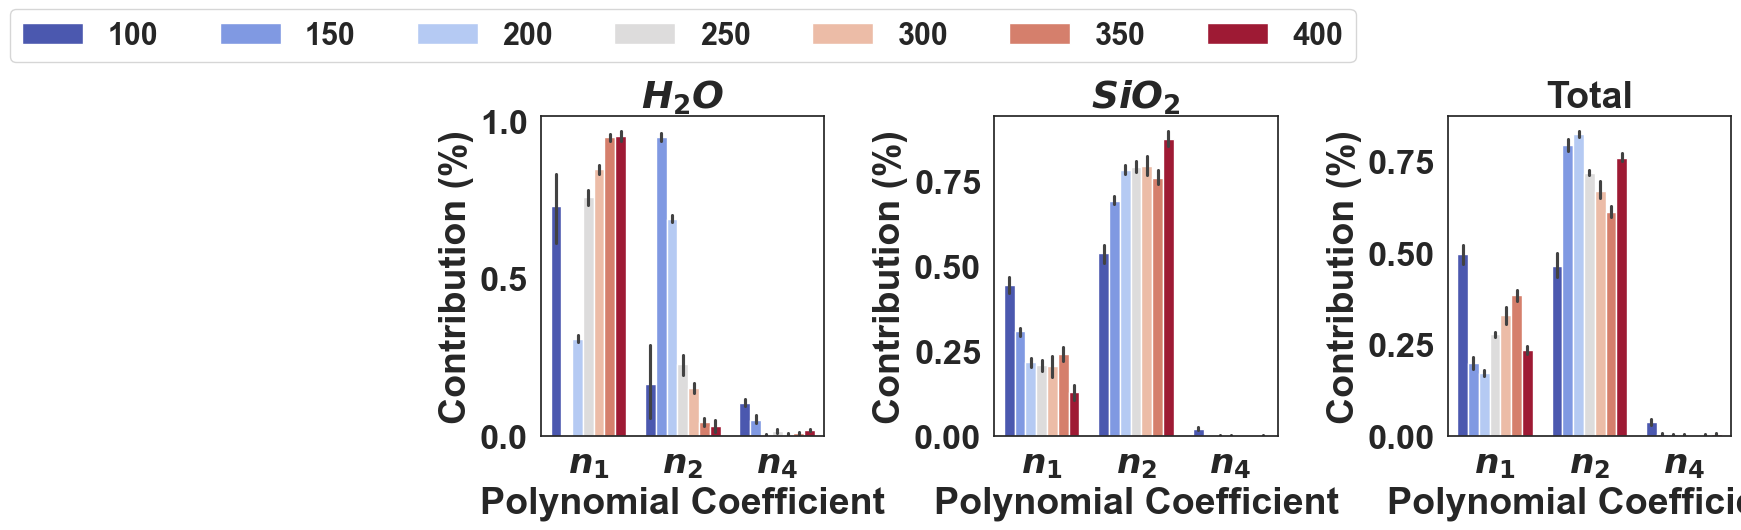

In [10]:
fig, axs = plt.subplots(ncols=3,figsize=(7*2,4))

for i, subset in enumerate(df_taylor_fit["Subset"].unique()):
    ax=axs[i]
    sns.barplot(data=df_taylor_fit.query("Subset == '%s'"%subset)
                , y='value'
                     , x='variable'
                     ,hue='Temperature (K)'
                ,palette="coolwarm"
                ,ax=ax
                ,legend=i==0
                    )
    
    if i==0:
        sns.move_legend(ax,'center',bbox_to_anchor=(0.5,legend_y),ncol=7,fontsize=22,title_fontsize=22,title="",)
    ax.set_xlabel("Polynomial Coefficient")
    ax.set_ylabel("Contribution (%)")
    ax.set_title(subset)
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.95, 
                    top=0.9, 
                    wspace=0.6, 
                    hspace=0.
                   )


In [11]:
def format_table(x):
    coeff,mettric=x.name
    result=x.copy()
    if coeff in ["a(T)","c(T)"]:
        result*=1e4
    if mettric == "mean":        
        result=result.map(lambda x : "%.1f"%x)
    else:
        result=result.map(lambda x : "%.2f"%x)
    return result

df_summary=df_power.groupby(["Temperature (K)","Subset"])[["a(T)","b(T)","c(T)"]].aggregate(["mean","std"])
df_summary_formatted=df_summary.apply(format_table).rename(columns={"mean":"$\mu$","std":"$\sigma$"})
print(df_summary_formatted.to_latex())

\begin{tabular}{llllllll}
\toprule
 &  & \multicolumn{2}{r}{a(T)} & \multicolumn{2}{r}{b(T)} & \multicolumn{2}{r}{c(T)} \\
 &  & $\mu$ & $\sigma$ & $\mu$ & $\sigma$ & $\mu$ & $\sigma$ \\
Temperature (K) & Subset &  &  &  &  &  &  \\
\midrule
\multirow[t]{3}{*}{100} & $H_2O$ & 14.2 & 4.09 & 2.2 & 0.53 & 6.3 & 2.31 \\
 & $SiO_2$ & 32.9 & 3.09 & 1.9 & 0.15 & -1.7 & 1.76 \\
 & Total & 26.5 & 3.26 & 2.0 & 0.21 & -0.4 & 1.83 \\
\cline{1-8}
\multirow[t]{3}{*}{150} & $H_2O$ & 17.1 & 0.60 & 2.3 & 0.09 & -17.2 & 0.32 \\
 & $SiO_2$ & 32.5 & 0.75 & 1.8 & 0.05 & -8.8 & 0.41 \\
 & Total & 26.9 & 0.87 & 1.9 & 0.06 & -9.5 & 0.47 \\
\cline{1-8}
\multirow[t]{3}{*}{200} & $H_2O$ & 33.4 & 0.45 & 1.8 & 0.03 & -1.7 & 0.26 \\
 & $SiO_2$ & 29.4 & 0.32 & 1.9 & 0.03 & -0.8 & 0.19 \\
 & Total & 26.7 & 0.40 & 1.9 & 0.03 & -0.6 & 0.22 \\
\cline{1-8}
\multirow[t]{3}{*}{250} & $H_2O$ & 53.7 & 1.53 & 1.4 & 0.06 & 7.6 & 1.02 \\
 & $SiO_2$ & 27.6 & 0.34 & 1.9 & 0.03 & -4.4 & 0.19 \\
 & Total & 27.4 & 0.46 & 1.8 & 0.03 

In [12]:
import ipywidgets as widgets

def power(x,a,b,c):
    return a*x**b+c


def fit_dos(df_mdanse,df_gmx,dos,emax,temperature,subset):
    if dos == "mdanse":
        df_tmp2=df_mdanse.query("0.1 <= `Energy Transfer (meV)` < %f and `Temperature (K)` == %d and Subset == '%s'"%(emax*2,temperature,subset))
        df_tmp=df_mdanse.query("0.1 <= `Energy Transfer (meV)` < %f and `Temperature (K)` == %d and Subset == '%s'"%(emax,temperature,subset))
    else:
        df_tmp2=df_gmx.query("0.1 <= `Energy Transfer (meV)` < %f and `Temperature (K)` == %d and Subset == '%s'"%(emax*2,temperature,subset))
        df_tmp=df_gmx.query("0.1 <= `Energy Transfer (meV)` < %f and `Temperature (K)` == %d and Subset == '%s'"%(emax,temperature,subset))
        
       
    xdata_ex=df_tmp2["Energy Transfer (meV)"].values
    ydata_ex=df_tmp2["Normalized Count"].values
    xdata=df_tmp["Energy Transfer (meV)"].values
    ydata=df_tmp["Normalized Count"].values
    popt, pcov = curve_fit(power, xdata, ydata,p0=[1,3,0],method='lm')
    cond_number=np.linalg.cond(pcov)
    cov_diag=np.diag(pcov)
    data_list.append({
            "Temperature (K)":temperature
            , "a(T)":popt[0]
            , "b(T)":popt[1]
            , "c(T)":popt[2] 
            ,"emax":emax
                         })
    
    fig, ax = plt.subplots(figsize=(8,5))
    df_fit=pd.concat([
        pd.DataFrame({"Energy Transfer (meV)":xdata_ex,"dos":ydata_ex,"data":"Simulation"})
        ,pd.DataFrame({"Energy Transfer (meV)":xdata,"dos":ydata,"data":"Fitted"})
        ,pd.DataFrame({"Energy Transfer (meV)":xdata,"dos": power(xdata, *popt),"data":"Fit:$ax^b+c$"})

    ],ignore_index=True)
    ax=sns.lineplot(data=df_fit
        , y='dos'
             , x='Energy Transfer (meV)'
            ,hue='data'
             ,palette='Set1'
             ,lw=3
            ,ax=ax
            )
#    ax.loglog()
    ax.set_title("Temperature: %d K. Power:%.1f Subset:%s emax=%.1f"%(temperature,popt[1],subset,emax),pad=25)
    sns.move_legend(ax,'center',bbox_to_anchor=(0.5,1.4),ncol=4,fontsize=22,title_fontsize=22,title="")

    parameters_str="\n".join(["%s=%.2e ± %.2e"%("abc"[i],x,dx) for i, (x,dx) in enumerate(zip(popt,cov_diag))])
    ax.text(1, 0.5,parameters_str,ha="left",va="center",weight='bold' ,transform=ax.transAxes)
 

d=widgets.interact(fit_dos
                 ,df_mdanse=widgets.fixed(df_dos_mdanse)
                 ,df_gmx=widgets.fixed(df_dos_gmx)
                 ,dos=["gmx","mdanse"]
                 ,emax=widgets.FloatSlider(min=1,max=3,value=1.5)
                 ,temperature=df_dos_mdanse["Temperature (K)"].unique()
                 ,subset=df_dos_mdanse["Subset"].unique()
                 )

interactive(children=(Dropdown(description='dos', options=('gmx', 'mdanse'), value='gmx'), FloatSlider(value=1…

In [13]:
def taylor_series(x,a0,a1,a2,a3,a4):
    return a0+a1*x+a2*x**2+a3*x**3+a4*x**4

def fit_dos(df_mdanse,df_gmx,dos,emax,temperature,subset):
    if dos == "mdanse":
        df_tmp2=df_mdanse.query("0.1 <= `Energy Transfer (meV)` < %f and `Temperature (K)` == %d and Subset == '%s'"%(emax*2,temperature,subset))
        df_tmp=df_mdanse.query("0.1 <= `Energy Transfer (meV)` < %f and `Temperature (K)` == %d and Subset == '%s'"%(emax,temperature,subset))
    else:
        df_tmp2=df_gmx.query("0.1 <= `Energy Transfer (meV)` < %f and `Temperature (K)` == %d and Subset == '%s'"%(emax*2,temperature,subset))
        df_tmp=df_gmx.query("0.1 <= `Energy Transfer (meV)` < %f and `Temperature (K)` == %d and Subset == '%s'"%(emax,temperature,subset))
        
       
    xdata_ex=df_tmp2["Energy Transfer (meV)"].values
    ydata_ex=df_tmp2["Normalized Count"].values
    xdata=df_tmp["Energy Transfer (meV)"].values
    ydata=df_tmp["Normalized Count"].values
    popt, pcov = curve_fit(taylor_series, xdata, ydata,p0=[1,1,1,1,1],bounds=([-np.inf,0,0,0,0],[np.inf,np.inf,np.inf,np.inf,np.inf]),method='trf')
    cond_number=np.linalg.cond(pcov)
    cov_diag=np.diag(pcov)
    data_list.append({
            "Temperature (K)":temperature
            , "a1(T)":popt[0]
            , "a2(T)":popt[1]
            , "b(T)":popt[2]
            , "c(T)":popt[3] 
            ,"emax":emax
                         })
    
    fig, ax = plt.subplots(figsize=(8,5))
    df_fit=pd.concat([
        pd.DataFrame({"Energy Transfer (meV)":xdata_ex,"dos":ydata_ex,"data":"Simulation"})
        ,pd.DataFrame({"Energy Transfer (meV)":xdata,"dos":ydata,"data":"Fitted"})
        ,pd.DataFrame({"Energy Transfer (meV)":xdata,"dos": taylor_series(xdata, *popt),"data":"Fit: $a0+a_1x+a_2x^2+a_3x^3+a_4x^4$"})

    ],ignore_index=True)
    ax=sns.lineplot(data=df_fit
        , y='dos'
             , x='Energy Transfer (meV)'
            ,hue='data'
             ,palette='Set1'
             ,lw=3
            ,ax=ax
            )
#    ax.loglog()
    ds_tmp=pd.Series({i+1:abs(x) for i,x in enumerate(popt[1:])})
    ax.set_title("Temperature: %d K. Power:%d Subset:%s emax=%.1f"%(temperature,ds_tmp.idxmax(),subset,emax),pad=25)

    parameters_str="\n".join(["$a_%d$=%.2e (%.1f %%)"%(i,x,dx) for i, (x,dx) in enumerate(zip(popt,100*np.abs(popt)/np.sum(np.abs(popt))))])
    ax.text(1, 0.5,parameters_str,ha="left",va="center",weight='bold' ,transform=ax.transAxes)
    
    sns.move_legend(ax,'center',bbox_to_anchor=(0.5,1.3),ncol=4,fontsize=22,title_fontsize=22,title="")



d=widgets.interact(fit_dos
                 ,df_mdanse=widgets.fixed(df_dos_mdanse)
                 ,df_gmx=widgets.fixed(df_dos_gmx)
                 ,dos=["gmx","mdanse"]
                 ,emax=widgets.FloatSlider(min=0.5,max=5,value=2.5)
                 ,temperature=df_dos_mdanse["Temperature (K)"].unique()
                 ,subset=df_dos_mdanse["Subset"].unique()
                 )

interactive(children=(Dropdown(description='dos', options=('gmx', 'mdanse'), value='gmx'), FloatSlider(value=2…

In [14]:
df_power.query("`Temperature (K)`==100 and Subset == '$H_2O$'")

,Temperature (K),a(T),b(T),c(T),emax,$a_0$,$a_1$,$a_2$,$a_4$,$n_1$,$n_2$,$n_4$,$\Delta a_0$,$\Delta a_1$,$\Delta a_2$,$\Delta a_4$,Subset
0,100,0.002075,1.380018,0.000253,1.50,0.000190,1.740161e-03,1.911572e-13,0.000279,8.619062e-01,9.468067e-11,0.138094,8.840091e-08,2.188169e-06,2.832717e-06,1.766823e-07,$H_2O$
1,100,0.002090,1.352007,0.000238,1.55,0.000164,1.824361e-03,4.659849e-11,0.000233,8.868713e-01,2.265279e-08,0.113129,8.534894e-08,2.002343e-06,2.457172e-06,1.377801e-07,$H_2O$
2,100,0.001977,1.533847,0.000332,1.60,0.000179,1.777351e-03,2.457302e-07,0.000256,8.740656e-01,1.208451e-04,0.125814,8.429932e-08,1.829666e-06,2.077581e-06,9.981223e-08,$H_2O$
3,100,0.002041,1.435206,0.000282,1.65,0.000137,1.904469e-03,3.540266e-09,0.000199,9.054137e-01,1.683097e-06,0.094585,8.317646e-08,1.716839e-06,1.854165e-06,8.061661e-08,$H_2O$
4,100,0.002053,1.419457,0.000273,1.70,0.000109,1.985864e-03,2.113281e-07,0.000166,9.226620e-01,9.818618e-05,0.077240,7.817353e-08,1.499861e-06,1.505929e-06,5.662571e-08,$H_2O$
5,100,0.001989,1.505010,0.000320,1.75,0.000122,1.950970e-03,1.098338e-07,0.000179,9.158388e-01,5.155900e-05,0.084110,7.483909e-08,1.369587e-06,1.311772e-06,4.490165e-08,$H_2O$
6,100,0.001952,1.550314,0.000345,1.80,0.000115,1.969557e-03,4.035188e-07,0.000172,9.195143e-01,1.883882e-04,0.080297,7.219935e-08,1.233334e-06,1.102808e-06,3.291838e-08,$H_2O$
7,100,0.001908,1.603916,0.000374,1.85,0.000119,1.959571e-03,4.424741e-07,0.000174,9.180757e-01,2.073029e-04,0.081717,7.176332e-08,1.172368e-06,1.002624e-06,2.738629e-08,$H_2O$
8,100,0.001772,1.766944,0.000457,1.90,0.000151,1.878935e-03,8.845275e-08,0.000196,9.053785e-01,4.262160e-05,0.094579,7.317174e-08,1.119994e-06,8.975500e-07,2.153770e-08,$H_2O$
9,100,0.001637,1.934458,0.000534,1.95,0.000185,1.792554e-03,1.828878e-08,0.000219,8.910692e-01,9.091257e-06,0.108922,7.159781e-08,1.050537e-06,8.071043e-07,1.780547e-08,$H_2O$
